# Dataset Aeroscapes
Aerial Semantic Segmentation (UAVs) Drone Dataset from Aeroscapes with 3269 Img.  

## Source 
1. Data: https://github.com/ishann/aeroscapes/tree/master?tab=readme-ov-file 
2. Paper: https://www.cs.cmu.edu/~deva/papers/aeroscapes.pdf:
    ```
    Ensemble Knowledge Transfer for Semantic Segmentation
    Ishan Nigam, Chen Huang, Deva Ramanan
    Proceedings of the 2018 IEEE Winter Conference on Applications of Computer Vision
    ```
3. (Additional) Kaggle challenge: https://www.kaggle.com/datasets/kooaslansefat/uav-segmentation-aeroscapes

## Base information 
Based on `REAMDE.md` from the dataset author: https://github.com/ishann/aeroscapes/tree/master?tab=readme-ov-file. 

### Introduction
The AeroScapes aerial semantic segmentation benchmark comprises of images captured using a commercial drone from an altitude range of 5 to 50 metres.
The dataset provides **3269 720p images** and ground-truth masks for **11 classes.**


### Instructions 
The data is available for download on [Google Drive](https://drive.google.com/file/d/1WmXcm0IamIA0QPpyxRfWKnicxZByA60v/view?usp=sharing). You can also use `scripts/download_data.py`.

On extraction, the downloaded file results in the following directory

        aeroscapes/
            JPEGImages/
                3269 RGB images.
            SegmentationClass/
                3269 ground-truth segmentation masks.
            Visualizations/
                3269 RGB ground-truth segmentation visualizations.
            ImageSets/
                Training and validation splits for data.


### Acknowledgements
We acknowledge the efforts of [Autel Robotics](https://www.autelrobotics.com) in the collection and manual annotation of the dataset.


# Exploratory Data Analysis
The first few steps of the analysis perform manual data sanity check. It could be extracted into a test suite later on.

## 1. Setup

In [ ]:
from pathlib import Path
from collections import Counter
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

# Resolve paths from project root regardless of where the kernel was started.
PROJECT_ROOT = (
    Path.cwd() if (Path.cwd() / "data" / "aeroscapes").exists() else Path.cwd().parent
)
os.chdir(PROJECT_ROOT)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("data/aeroscapes")
IMG_DIR = DATA_DIR / "JPEGImages"
MASK_DIR = DATA_DIR / "SegmentationClass"
VIS_DIR = DATA_DIR / "Visualizations"
SPLITS_DIR = DATA_DIR / "ImageSets"

# Official Aeroscapes class names. Index 0 is background / unlabeled.
CLASS_NAMES = [
    "background",  # 0
    "person",  # 1
    "bike",  # 2
    "car",  # 3
    "drone",  # 4
    "boat",  # 5
    "animal",  # 6
    "obstacle",  # 7
    "construction",  # 8
    "vegetation",  # 9
    "road",  # 10
    "sky",  # 11
]
NUM_CLASSES = len(CLASS_NAMES)
print(f"{NUM_CLASSES} classes: {CLASS_NAMES}")

## 2. Loading the training split

We use the official train split from `ImageSets/trn.txt` (each line is an image stem). All EDA below uses **only the training images** — anything we derive from the data (class weights, normalization stats) becomes a model parameter, so touching validation pixels would leak.

In [6]:
# Total dataset size — sanity-check the advertised 3269.
all_jpgs = sorted(IMG_DIR.glob("*.jpg"))
all_masks = sorted(MASK_DIR.glob("*.png"))
print(f"JPEG images: {len(all_jpgs)}")
print(f"Masks:       {len(all_masks)}")
assert len(all_jpgs) == len(all_masks) == 3269, (
    "Counts don't match the 3269 advertised in the paper."
)

# Filename pairing — every JPEG should have a matching PNG mask.
img_stems = {p.stem for p in all_jpgs}
mask_stems = {p.stem for p in all_masks}
missing_masks = img_stems - mask_stems
missing_imgs = mask_stems - img_stems
print(f"Images without masks: {len(missing_masks)}")
print(f"Masks without images: {len(missing_imgs)}")

JPEG images: 3269
Masks:       3269
Images without masks: 0
Masks without images: 0


In [7]:
# Load the official training split.
trn_split_file = SPLITS_DIR / "trn.txt"
with open(trn_split_file) as f:
    train_stems = [line.strip() for line in f if line.strip()]

print(f"Training images according to ImageSets/trn.txt: {len(train_stems)}")
print(f"First 5 stems: {train_stems[:5]}")

# Build full paths for the training set.
train_img_paths = [IMG_DIR / f"{s}.jpg" for s in train_stems]
train_mask_paths = [MASK_DIR / f"{s}.png" for s in train_stems]

# Make sure every training file actually exists on disk.
missing = [p for p in train_img_paths + train_mask_paths if not p.exists()]
assert not missing, f"{len(missing)} files listed in trn.txt are missing on disk"
print("All training files present on disk.")

Training images according to ImageSets/trn.txt: 2621
First 5 stems: ['000001_001', '000001_002', '000001_003', '000001_004', '000001_005']
All training files present on disk.


## 3. Sample images and masks

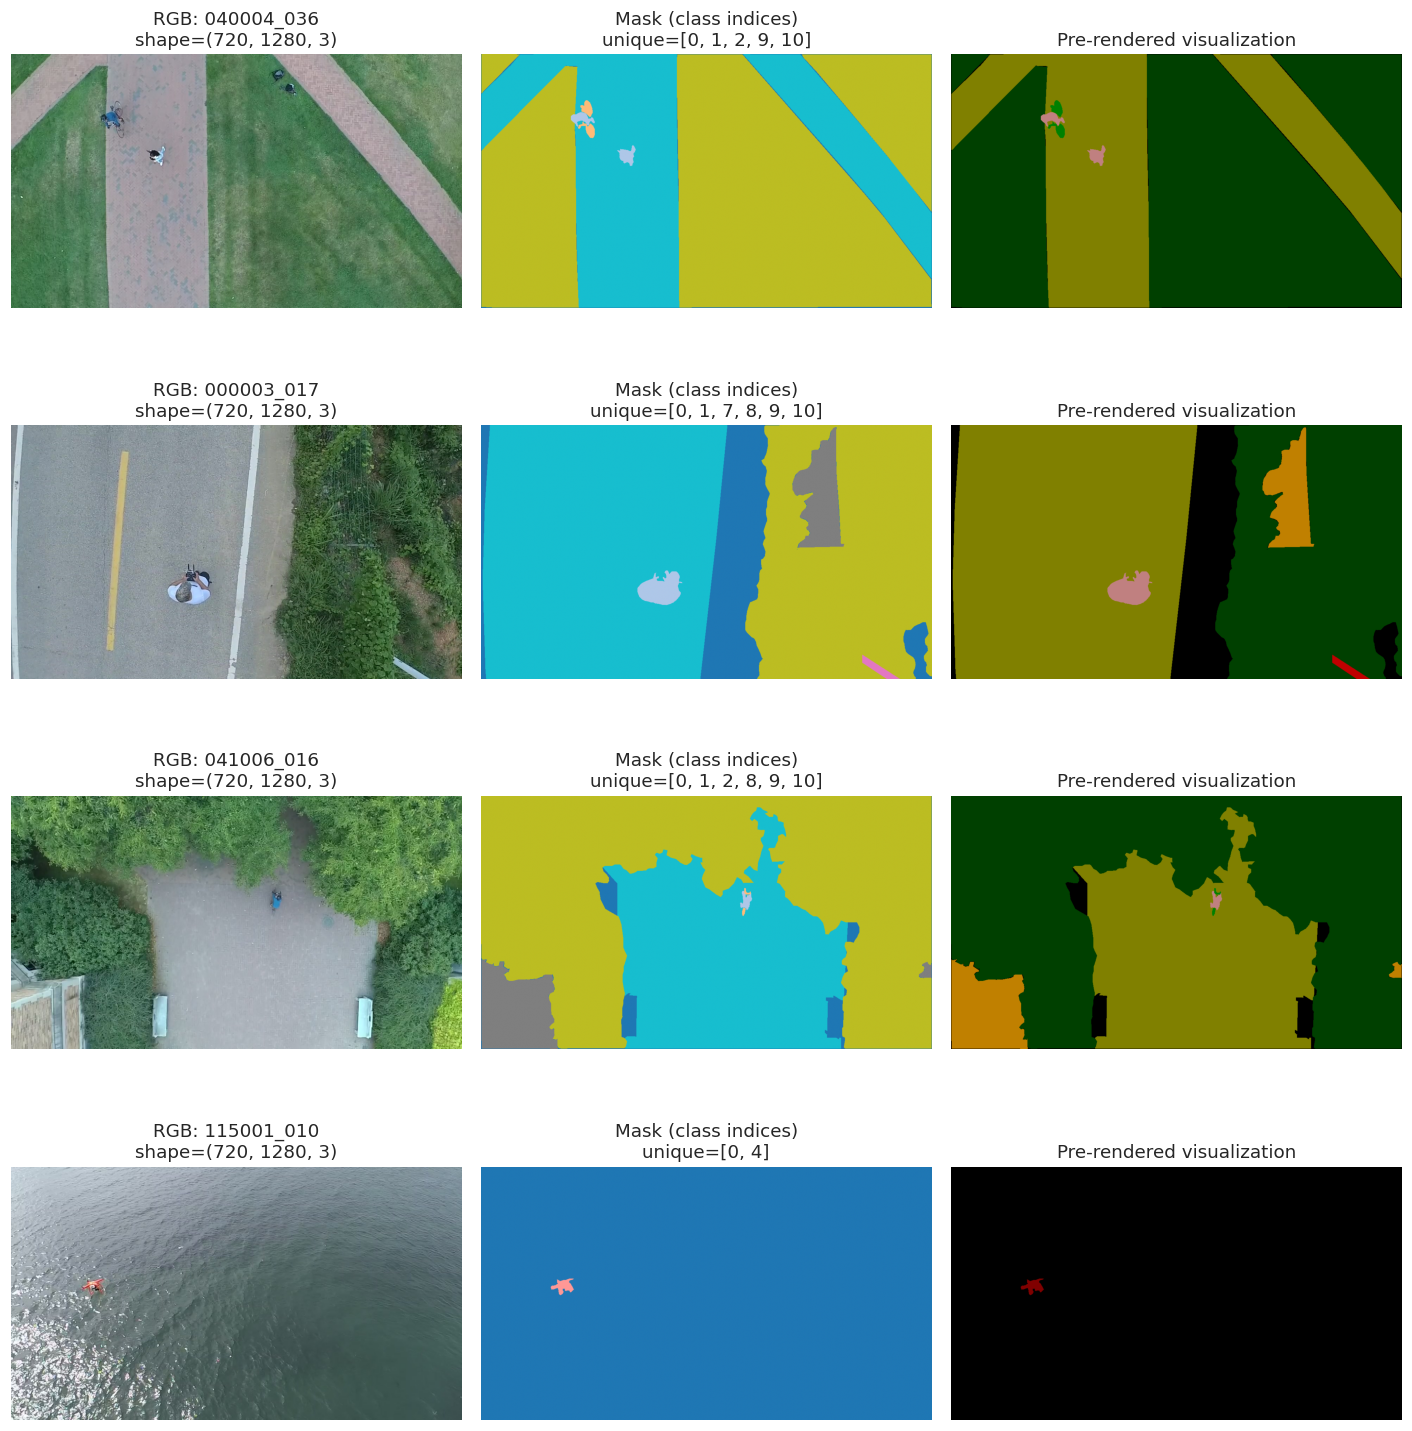

In [8]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(train_stems), size=4, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(13, 14))
for row, idx in enumerate(sample_idx):
    img = np.array(Image.open(train_img_paths[idx]).convert("RGB"))
    mask = np.array(Image.open(train_mask_paths[idx]))  # mode preserved on purpose
    vis = np.array(Image.open(VIS_DIR / f"{train_stems[idx]}.png").convert("RGB"))

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"RGB: {train_stems[idx]}\nshape={img.shape}")
    axes[row, 1].imshow(mask, cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    axes[row, 1].set_title(
        f"Mask (class indices)\nunique={sorted(np.unique(mask).tolist())}"
    )
    axes[row, 2].imshow(vis)
    axes[row, 2].set_title("Pre-rendered visualization")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Image properties: dimensions, modes, pixel ranges

Three things we need to know before writing the `Dataset`:
- Are all images the same size (1280x 720)? (decides whether one resize policy is enough)
- Are images standard RGB uint8?
- Are masks single-channel index maps or RGB-encoded? (RGB would force a color→class decoding step)

In [9]:
# We only need to OPEN images (PIL is lazy) to read metadata — no need to decode pixels yet.
img_sizes = Counter()
img_modes = Counter()

for p in tqdm(train_img_paths, desc="Scanning image metadata"):
    with Image.open(p) as im:
        img_sizes[im.size] += 1
        img_modes[im.mode] += 1

print("Image sizes (W, H):", dict(img_sizes))
print("Image modes:       ", dict(img_modes))

Scanning image metadata:   0%|          | 0/2621 [00:00<?, ?it/s]

Image sizes (W, H): {(1280, 720): 2621}
Image modes:        {'RGB': 2621}


In [10]:
# Inspect mask format — this is where the indexed-vs-RGB question gets settled.
mask_sizes = Counter()
mask_modes = Counter()
mask_unique_values = set()

for p in tqdm(train_mask_paths, desc="Scanning mask metadata"):
    with Image.open(p) as m:
        mask_sizes[m.size] += 1
        mask_modes[m.mode] += 1
        # Read pixels for every mask so we know the GLOBAL set of values used.
        mask_unique_values.update(np.unique(np.array(m)).tolist())

print("Mask sizes (W, H):     ", dict(mask_sizes))
print("Mask modes:            ", dict(mask_modes))
print("Unique values in masks:", sorted(mask_unique_values))
print(f"Number of unique values: {len(mask_unique_values)} (expected: {NUM_CLASSES})")

Scanning mask metadata:   0%|          | 0/2621 [00:00<?, ?it/s]

Mask sizes (W, H):      {(1280, 720): 2621}
Mask modes:             {'L': 2621}
Unique values in masks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Number of unique values: 12 (expected: 12)


**Confirmed for preprocessing:**
- Images: all 1280×720 RGB — single resize policy works; aspect ratio 16:9.
- Masks: mode `L` (single-channel index map), values exactly `{0, ..., 11}`. **No color decoding needed**, no `255` ignore label to mask out.
- Mask loading: `np.array(Image.open(p))` returns class indices directly — cast to `torch.long` for `CrossEntropyLoss`.
- Resize interpolation: **`BILINEAR` for images, `NEAREST` for masks** (any blending of class indices would create invalid intermediate values like `4.7`).

In [ ]:
# Per-channel RGB mean/std on the training split, to compare against ImageNet
# normalization. Subsample 500 images — enough for stable estimates given each
# image has ~1M pixels.
n_pixels = 0
channel_sum = np.zeros(3, dtype=np.float64)
channel_sq_sum = np.zeros(3, dtype=np.float64)

stat_sample = rng.choice(
    len(train_img_paths), size=min(500, len(train_img_paths)), replace=False
)

for idx in tqdm(stat_sample, desc="Computing RGB stats"):
    arr = (
        np.array(Image.open(train_img_paths[idx]).convert("RGB"), dtype=np.float64)
        / 255.0
    )
    n_pixels += arr.shape[0] * arr.shape[1]
    channel_sum += arr.sum(axis=(0, 1))
    channel_sq_sum += (arr**2).sum(axis=(0, 1))

channel_mean = channel_sum / n_pixels
channel_std = np.sqrt(channel_sq_sum / n_pixels - channel_mean**2)

print(f"Aeroscapes train RGB mean: {channel_mean.round(4).tolist()}")
print(f"Aeroscapes train RGB std:  {channel_std.round(4).tolist()}")
print("ImageNet RGB mean:         [0.485, 0.456, 0.406]")
print("ImageNet RGB std:          [0.229, 0.224, 0.225]")

**Normalization decision.** Aeroscapes means `[0.44, 0.51, 0.46]` vs ImageNet `[0.49, 0.46, 0.41]` — the green channel is shifted up ~0.05 (vegetation-dominated scenes) and red shifted down. Std `[0.18, 0.16, 0.19]` is noticeably lower than ImageNet's `~0.22` (lower contrast, narrower dynamic range — typical for outdoor aerial photos).

For preprocessing: **use ImageNet mean/std** when training with a pretrained backbone — the differences are small and the backbone expects that input distribution. Custom stats would only matter **if we train from scratch** (TODO KACPER WERA).**

## 5. Class imbalance — three views
- **(a) Pixel share** — fraction of all training pixels belonging to each class. Drives loss weighting.
- **(b) Image presence** — fraction of training images that contain the class at all. Drives class-balanced sampling.
- **(c) Mean coverage when present** — when the class IS in an image, what fraction does it cover. Distinguishes *rare* (few images) from *small* (many images, tiny objects) — these need different mitigations.

In [12]:
# Single pass — for each mask, count pixels per class and record presence.
pixel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
image_presence = np.zeros(NUM_CLASSES, dtype=np.int64)
# Per-image fraction per class — used for (c) and for the class-richness histogram.
per_image_fractions = np.zeros((len(train_mask_paths), NUM_CLASSES), dtype=np.float32)

for i, p in enumerate(tqdm(train_mask_paths, desc="Counting class pixels")):
    mask = np.array(Image.open(p))
    counts = np.bincount(mask.ravel(), minlength=NUM_CLASSES)
    # If a mask had a value >= NUM_CLASSES we'd see it here.
    if len(counts) > NUM_CLASSES:
        print(f"WARNING: {p.name} contains class indices outside 0..{NUM_CLASSES - 1}")
        counts = counts[:NUM_CLASSES]
    pixel_counts += counts
    total = mask.size
    per_image_fractions[i] = counts / total
    image_presence += (counts > 0).astype(np.int64)

n_train = len(train_mask_paths)
total_pixels = pixel_counts.sum()

# Build a tidy summary table.
# Mean coverage when present: average per-image fraction over only the images that contain the class.
mean_coverage_when_present = np.zeros(NUM_CLASSES)
for c in range(NUM_CLASSES):
    present = per_image_fractions[:, c] > 0
    if present.any():
        mean_coverage_when_present[c] = per_image_fractions[present, c].mean()

summary = (
    pd.DataFrame(
        {
            "class": CLASS_NAMES,
            "pixel_share_pct": 100 * pixel_counts / total_pixels,
            "image_presence_pct": 100 * image_presence / n_train,
            "mean_coverage_when_present_pct": 100 * mean_coverage_when_present,
            "total_pixels": pixel_counts,
        }
    )
    .sort_values("pixel_share_pct", ascending=False)
    .reset_index(drop=True)
)

summary.style.format(
    {
        "pixel_share_pct": "{:.2f}%",
        "image_presence_pct": "{:.1f}%",
        "mean_coverage_when_present_pct": "{:.2f}%",
        "total_pixels": "{:,}",
    }
)

Counting class pixels:   0%|          | 0/2621 [00:00<?, ?it/s]

,class,pixel_share_pct,image_presence_pct,mean_coverage_when_present_pct,total_pixels
0,vegetation,35.39%,92.1%,38.43%,"854,898,289"
1,road,31.61%,87.5%,36.12%,"763,651,425"
2,background,23.01%,100.0%,23.01%,"555,900,697"
3,sky,4.64%,14.8%,31.32%,"111,987,782"
4,construction,3.79%,55.5%,6.82%,"91,507,497"
5,obstacle,0.60%,66.1%,0.91%,"14,487,197"
6,person,0.43%,84.8%,0.51%,"10,402,499"
7,car,0.34%,29.1%,1.18%,"8,283,476"
8,animal,0.07%,2.8%,2.47%,"1,663,688"
9,bike,0.06%,41.6%,0.15%,"1,531,710"


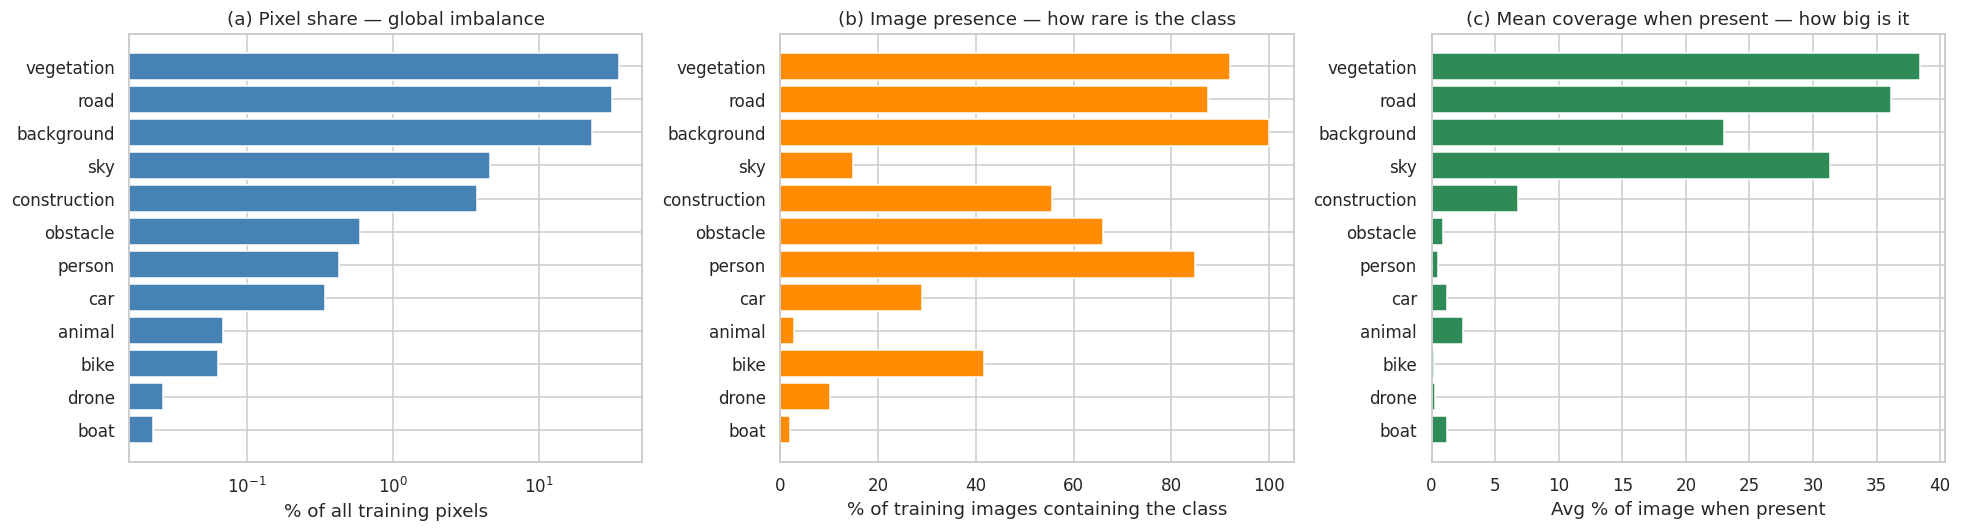

In [13]:
# Visualize all three views side-by-side.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ordered = summary.sort_values("pixel_share_pct", ascending=True)

axes[0].barh(ordered["class"], ordered["pixel_share_pct"], color="steelblue")
axes[0].set_xlabel("% of all training pixels")
axes[0].set_title("(a) Pixel share — global imbalance")
axes[0].set_xscale("log")

axes[1].barh(ordered["class"], ordered["image_presence_pct"], color="darkorange")
axes[1].set_xlabel("% of training images containing the class")
axes[1].set_title("(b) Image presence — how rare is the class")

axes[2].barh(
    ordered["class"], ordered["mean_coverage_when_present_pct"], color="seagreen"
)
axes[2].set_xlabel("Avg % of image when present")
axes[2].set_title("(c) Mean coverage when present — how big is it")

plt.tight_layout()
plt.show()

**What the three views tell us (concrete findings):**

- **3 dominant classes**: vegetation (35.4% pixels / 92% images), road (31.6% / 87.5%), background (23.0% / 100% — present in every single image). Together ~90% of all pixels. Without weighting, the loss will be driven almost entirely by these.
- **Small but ubiquitous** (low pixel share, high presence): person (0.43% / 85%), bike (0.06% / 42%), obstacle (0.6% / 66%). These appear in many scenes but as tiny objects — IoU will collapse without pixel-level loss weighting.
- **Genuinely rare** (low on both): boat (0.02% / 1.9%), animal (0.07% / 2.8%), drone (0.03% / 10%). Loss weighting alone is not enough — also need `WeightedRandomSampler` so the model sees them more than a handful of times per epoch.
- **Bursty**: sky (only 15% of images, but covers ~31% when present — open-aerial shots). Augmentation crops should not throw away the few sky-containing images.

**Preprocessing implication**: combine median-frequency loss weights *and* a sampler that upweights images containing rare classes. Background is huge but not informative — consider downweighting it explicitly in the loss (or using `ignore_index`).

## 6. Class richness per image

How many distinct classes appear in a typical image — relevant for choosing crop size: a crop too small can drop a tiny rare class entirely, starving it further.

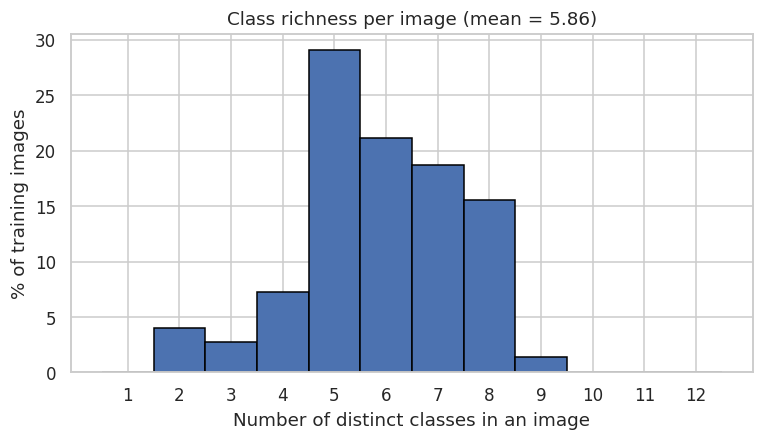

Min: 2, Max: 9, Median: 6


In [19]:
classes_per_image = (per_image_fractions > 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    classes_per_image,
    bins=range(1, NUM_CLASSES + 2),
    edgecolor="black",
    align="left",
    weights=np.ones_like(classes_per_image) / len(classes_per_image) * 100,
)
ax.set_xlabel("Number of distinct classes in an image")
ax.set_ylabel("% of training images")
ax.set_title(f"Class richness per image (mean = {classes_per_image.mean():.2f})")
ax.set_xticks(range(1, NUM_CLASSES + 1))
plt.show()

print(
    f"Min: {classes_per_image.min()}, Max: {classes_per_image.max()}, Median: {int(np.median(classes_per_image))}"
)

**Finding**: median is **6** classes per image (range 2–9) — these are not simple 2–3 class scenes. Most images cover a substantial slice of the label set, so even relatively small random crops should still see a meaningful class mix. Implication for preprocessing: aggressive cropping (e.g. 256×256 from 720p source ≈ 1/8 of width) is safe — most crops will retain enough scene context, and the dataset is small (2621 train) enough that we benefit from many crops per image as augmentation.

## 7. Class co-occurrence

`P(col | row)` — given an image contains the row class, how often does it also contain the column class? Lets us see whether a rare class is locked to a specific backdrop (so the model could cheat using context).

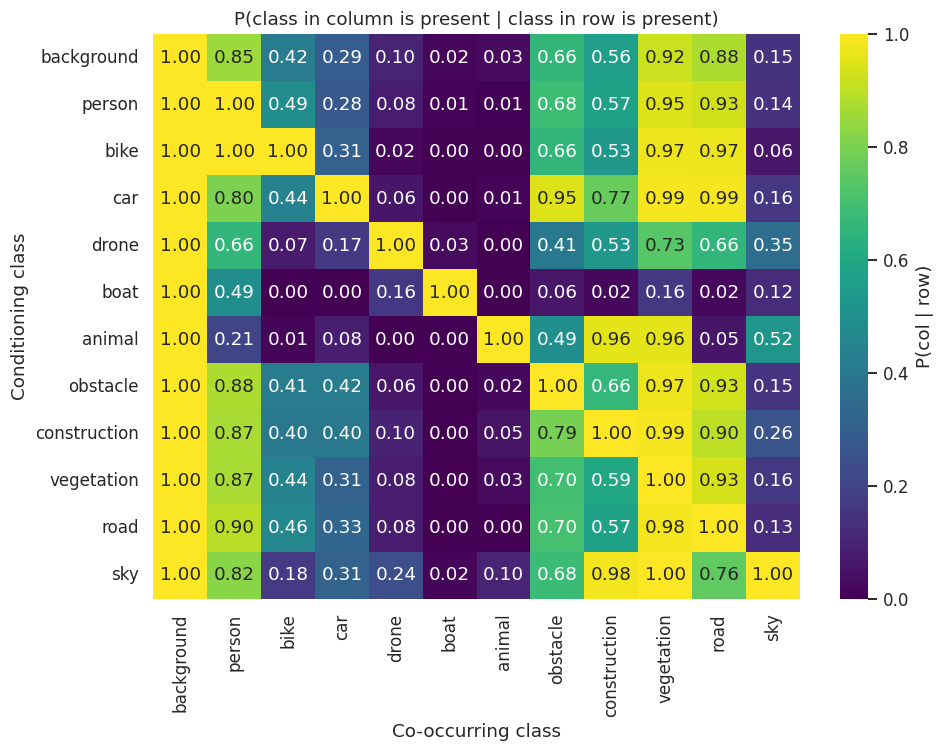

Co-occurrence matrix P(col | row):
              background  person   bike    car  drone   boat  animal  obstacle  construction  vegetation   road    sky
background         100.0    84.8   41.6   29.1   10.1    1.9     2.8      66.1          55.5        92.1   87.5   14.8
person             100.0   100.0   49.0   27.5    7.8    1.1     0.7      68.4          57.0        94.6   92.7   14.3
bike               100.0    99.8  100.0   30.6    1.7    0.0     0.1      65.5          53.4        97.4   97.3    6.2
car                100.0    80.3   43.8  100.0    5.8    0.0     0.8      94.9          76.8        98.6   98.6   16.0
drone              100.0    65.9    7.2   16.7  100.0    3.0     0.0      40.5          53.4        73.5   65.5   35.2
boat               100.0    49.0    0.0    0.0   16.3  100.0     0.0       6.1           2.0        16.3    2.0   12.2
animal             100.0    20.5    1.4    8.2    0.0    0.0   100.0      49.3          95.9        95.9    5.5   52.1
obstacle     

In [25]:
# Conditional co-occurrence: rows = condition class, cols = co-occurring class.
# Cell (i, j) = P(class j present | class i present).
presence_matrix = (per_image_fractions > 0).astype(np.int64)  # (N, C)
joint = (
    presence_matrix.T @ presence_matrix
)  # (C, C) — count of images where both i and j present
row_totals = presence_matrix.sum(axis=0)  # (C,) — count of images containing class i

with np.errstate(divide="ignore", invalid="ignore"):
    cooccurrence = np.where(row_totals[:, None] > 0, joint / row_totals[:, None], 0.0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cooccurrence,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
    cbar_kws={"label": "P(col | row)"},
)
ax.set_title("P(class in column is present | class in row is present)")
ax.set_xlabel("Co-occurring class")
ax.set_ylabel("Conditioning class")
plt.tight_layout()
plt.show()

# print numerical as well
cooccurrence_df = pd.DataFrame(cooccurrence, index=CLASS_NAMES, columns=CLASS_NAMES)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
print("Co-occurrence matrix P(col | row):")
print((cooccurrence_df * 100).round(1))

**Co-occurrence findings:**
- `background` is in **100%** of all images regardless of conditioning class — it acts as a true "everything else" label. Downweighting it (or using `ignore_index=0`) will not lose information about other classes.
- **Boat** is highly isolated: when boat is present, road appears in only 2% of images and vegetation in 16% (vs. 87–92% baseline). The model could shortcut "water-like backdrop → boat" — worth checking on validation.
- **Animal** rarely co-occurs with road (5.5%) but almost always with construction (96%) and vegetation (96%) — rural scenes only.
- **Drone** has the most distinctive context: 35% with sky vs. 15% baseline (drones photographed against sky), and lower co-occurrence with bike/animal.
- **Sky** rarely contains bike (6%) — bike scenes are typically low-altitude, sky-less.

These are **shortcut risks**, not preprocessing changes — but they motivate keeping color jitter and contrast augmentations to discourage backdrop-based shortcuts.

## 8. Suggested class weights

Two standard formulas applied to our pixel counts. These are baselines to drop into the `DataModule.setup()` and pass to `CrossEntropyLoss(weight=...)`.

In [16]:
freq = pixel_counts / pixel_counts.sum()

# Inverse frequency — simple, can be too aggressive on extremely rare classes.
inv_freq = 1.0 / (freq + 1e-6)
inv_freq_normalized = inv_freq / inv_freq.mean()  # so weights average to 1

# Median frequency balancing (Eigen & Fergus 2015) — gentler, more numerically stable.
median_freq = np.median(freq[freq > 0])
median_balanced = median_freq / (freq + 1e-6)

weights_df = pd.DataFrame(
    {
        "class": CLASS_NAMES,
        "pixel_share_pct": 100 * freq,
        "weight_inv_freq": inv_freq_normalized,
        "weight_median_freq": median_balanced,
    }
).sort_values("pixel_share_pct", ascending=False)

weights_df.style.format(
    {
        "pixel_share_pct": "{:.3f}%",
        "weight_inv_freq": "{:.2f}",
        "weight_median_freq": "{:.2f}",
    }
)

,class,pixel_share_pct,weight_inv_freq,weight_median_freq
9,vegetation,35.392%,0.00,0.01
10,road,31.614%,0.00,0.02
0,background,23.014%,0.00,0.02
11,sky,4.636%,0.02,0.11
8,construction,3.788%,0.03,0.14
7,obstacle,0.600%,0.17,0.86
1,person,0.431%,0.24,1.20
3,car,0.343%,0.30,1.50
6,animal,0.069%,1.47,7.47
2,bike,0.063%,1.59,8.11


## 9. Summary of findings → preprocessing decisions

Each row links one EDA finding to a concrete choice for `AeroScapesDataset` / `AeroScapesDataModule`:

| Finding | Decision |
|---|---|
| 3269 imgs ↔ 3269 masks, all paired by stem | Trust the structure — no filtering needed |
| All images 1280×720 RGB uint8 | Single resize policy; aspect ratio 16:9 (preserve or square-crop) |
| Masks are mode `L`, values exactly `{0..11}`, no `255` | Load as `np.array(...).astype(np.int64)` — no color decoding, no ignore mask |
| Mask values are class indices, not continuous | Resize: `BILINEAR` for image, **`NEAREST` for mask** |
| Train RGB mean `[0.44, 0.51, 0.46]` close to ImageNet `[0.49, 0.46, 0.41]` | Use ImageNet mean/std (we'll use a pretrained backbone) |
| 3 classes (vegetation, road, background) hold ~90% of pixels; bottom 4 (boat, animal, drone, bike) hold <0.2% combined | Median-frequency class weights for `CrossEntropyLoss`; consider downweighting / `ignore_index` for background |
| boat (1.9%), animal (2.8%), drone (10%) appear in very few *images* | `WeightedRandomSampler` on top of loss weighting — pixel weights alone don't help if a class is missing from most batches |
| person, bike, obstacle: high presence (42–85%) but tiny pixel share | Per-pixel loss weighting will already help; avoid heavy downsampling that erases small objects (keep ≥ 360p, prefer crops over resize for fine detail) |
| Median 6 classes per image (range 2–9) | Crops up to ~1/8 of width still see enough class diversity — random-crop augmentation is safe |
| Use the official `ImageSets/trn.txt` / `val.txt` split | No `random_split` — keeps results comparable to published numbers |

These map directly onto the pieces the next stage (`src/datasets/aeroscapes.py` + DataModule) needs to implement.